# Prediction Model
This code uses the DataPrep.py file to import required dataframes and then uses the elastic_net function to train and test the elastic net regression model on the data extracted from the original csv files. The performance of the model for each target audience is then printed, along with the regression plots. 

First, the DataPrep script file is imported so all the data is available in memory. Then, other libraries and modules needed to execute the code are also imported.

In [1]:
from DataPrep import * 

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

### Elastic Net Regression
The elastic net regression model was selected after performing a comparative study on several candidate models for the task of predicting conference registrations based on previous data. The elastic net model showed the best performance and was therefore selected as the model of choice for this task. Here, we create a function to perform elastic net regression on the day-wise dataframes and produce the results (plots and metrics) of the model to show its performance.

In [3]:
# Create a new dataframe to store the results of the elastic net model
df_elasticnet_results = pd.DataFrame()

"""function to perform elastic net regression on the day-wise dataframes"""
def elastic_net (dataframe, audience_name):
    global df_elasticnet_results

    max_days = dataframe["Days to Event"].max()
    # Reverse the order of the days to event column to start from 0 to enable fit_intercept = False
    dataframe["Day #"] = (max_days + 1) - dataframe["Days to Event"] 

    X = dataframe[["Day #", "Advertisement Status"]] # Create a feature matrix
    y = dataframe["Booking Count"] # Create a target vector for booking count

    # Split the data into training and testing sets. Stratify ensures that the train and test sets have similar
    # proportions of days with and without advertisements.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1, stratify = X["Advertisement Status"]) 

    # Create a new dataframe for the test set
    X_test_df = pd.DataFrame(X_test, columns = ["Day #", "Advertisement Status"])
    # Create a new series for the test set
    y_test_series = pd.Series(y_test, name = "Booking Count") 
    # Combine the testing data into a single dataframe
    test_df = pd.concat([X_test_df.reset_index(drop = True), y_test_series.reset_index(drop = True)], axis = 1)
    # Sort the testing data by days to event in ascending order
    test_df = test_df.sort_values(by = "Day #", ascending = True)  

    # Sorted feature matrix
    X_test_sorted = test_df[["Day #", "Advertisement Status"]]
    # Sorted target vector
    y_test_sorted = test_df["Booking Count"] 
    # Feature matrix for days with advertisements
    X_ad_active = X_test_sorted[X_test_sorted["Advertisement Status"] == 1] 
    # Feature matrix for days without advertisements
    X_ad_inactive = X_test_sorted[X_test_sorted["Advertisement Status"] == 0] 

    # Create an elastic net model
    regr = ElasticNetCV(l1_ratio = [.1, .3, .5, .7, .9, .95, .99], cv = 10, random_state = 1, fit_intercept = False) 

    # Fit the model to the training data
    regr.fit(X_train, y_train)
    # Make predictions using the testing dataset
    pred = regr.predict(X_test_sorted) 
    # Make predictions for days with and without advertisements
    pred_ad_inactive = regr.predict(X_ad_inactive) 
    if X_ad_active.empty == False:
        pred_ad_active = regr.predict(X_ad_active)
    else:
        pred_ad_active = pred_ad_inactive

    # Create a new dataframe for the predictions
    predplot_df = X_test_sorted.copy() 
    # Add a new column for the predicted booking count
    predplot_df["Predicted Count"] = pred 
    # Create a new dataframe for days with advertisements
    ads_active_df = predplot_df[predplot_df["Advertisement Status"] == 1] 

    # Calculate the mean squared error
    mse = mean_squared_error(y_test_sorted, pred)
    # Calculate the coefficient of determination (r-squared)
    r2 = r2_score(y_test_sorted, pred)
    # Get the optimal alpha value
    alpha = regr.alpha_ 
    # Get the optimal l1 ratio
    l1_ratio = regr.l1_ratio_ 
    # Calculate the variance of the test data
    variance = np.var(y_test_sorted)
    # Calculate the relative mean squared error
    relative_mse = mse / variance 
    # Calculate the mean absolute error
    mae = mean_absolute_error(y_test_sorted, pred) 
    # Calculate the range of the test data
    range_y = y_test_sorted.max() - y_test_sorted.min()
    # Calculate the relative mean absolute error
    relative_mae = mae / range_y 
    # Calculate the effect of advertisements on the predicted booking count
    ad_effect = (pred_ad_active.mean() - pred_ad_inactive.mean()) / pred_ad_inactive.mean() 
    
    # Create a dictionary with important metrics of the elastic net model
    results = {
            "Target Audience": audience_name,
            "Alpha": round(alpha, 2),
            "L1 Ratio": l1_ratio,
            "Mean Squared Error": round(mse, 2),
            "R-squared": round(r2, 2),
            "% R-squared": round(r2 * 100, 2),
            "% Relative MSE": round(relative_mse * 100, 2), 
            "Mean Absolute Error": round(mae, 2),
            "Relative MAE": round(relative_mae, 2),
            "% Accuracy": round((1 - relative_mae) * 100, 2),
            "% Booking Increase per Day in Advertisement Weeks": round(ad_effect * 100, 2) 
        }
    
    # setting index to 0 is important when assigning a single row to a dataframe
    new_row = pd.DataFrame(results, index = [0]) 
    # Add the results to the dataframe
    df_elasticnet_results = pd.concat([df_elasticnet_results, new_row], ignore_index = True) 

    # Create a new figure
    plt.figure(figsize = (10, 6))     
    # Create a scatter plot of the actual booking count
    plt.scatter(X_test_sorted["Day #"], y_test_sorted, color = "black", label = "Actual") 
    # Create a line plot of the predicted booking count
    plt.plot(X_test_sorted["Day #"], pred, color = "blue", linewidth = 1, label = "Predicted") 
    # Create a scatter plot of days with advertisements
    plt.scatter(ads_active_df["Day #"], ads_active_df["Predicted Count"], color = "red", label = "Advertisement Active") 
    # Set the title of the plot
    plt.title("Elastic Net Regression for " + audience_name)
    # Set the x-axis label
    plt.xlabel("Day #") 
    # Set the y-axis label
    plt.ylabel("Booking Count")
    # Add a legend to the plot
    plt.legend()
    # Display the plot
    plt.show() 


Now, the elastic net model is trained and tested first on specific data for each target audience, and then the model is trained and tested on the cumulative data which is applicable to general/other target audiences. The results of the model's performance are printed as well.

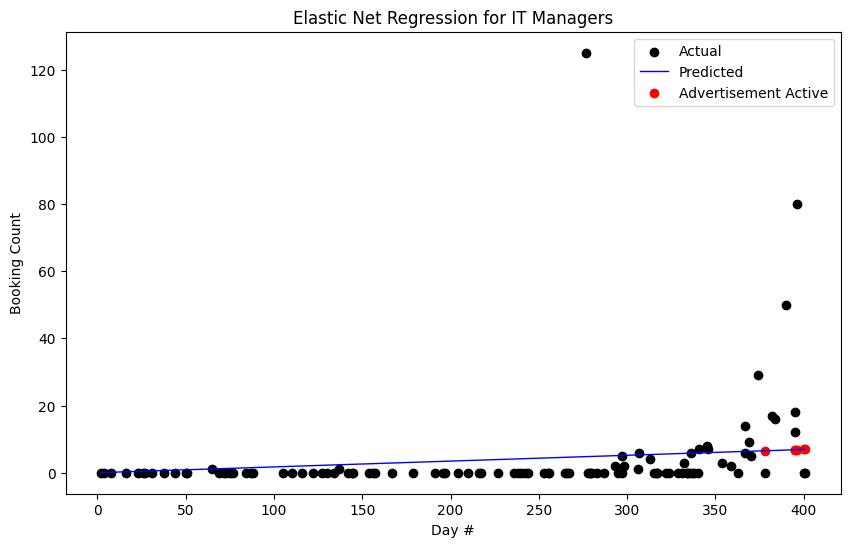

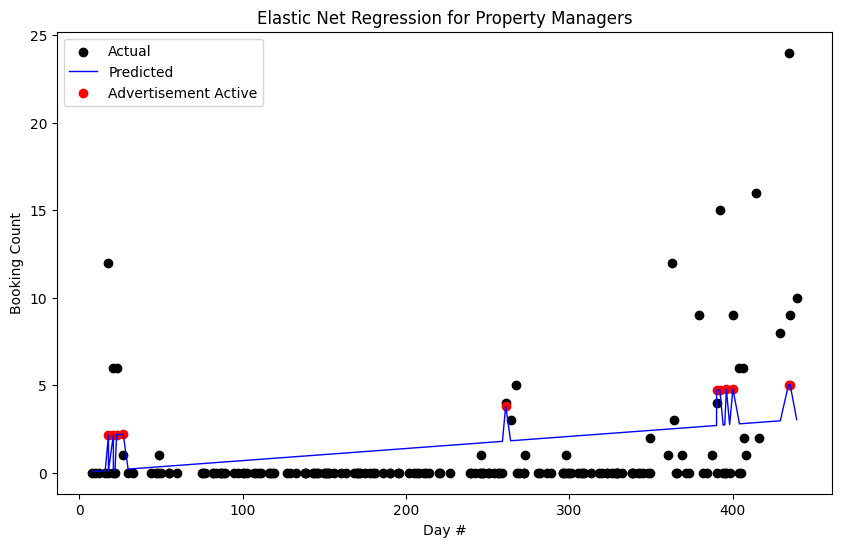

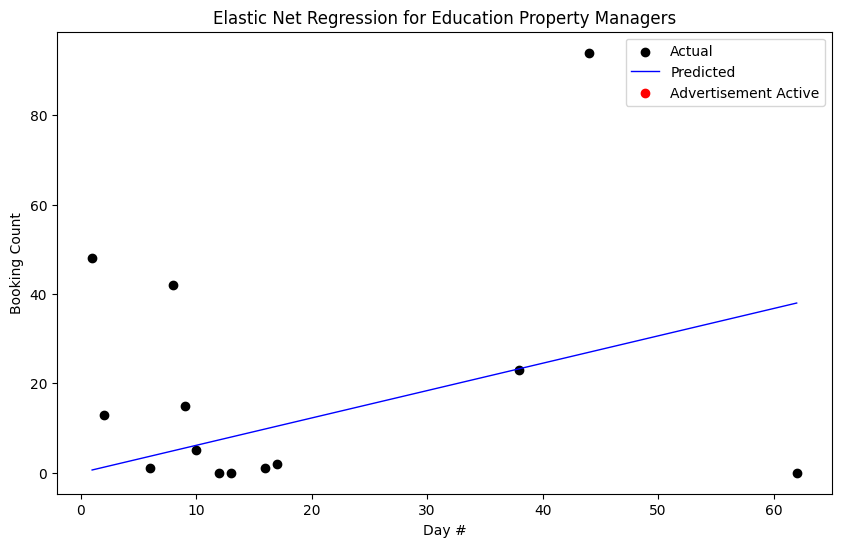

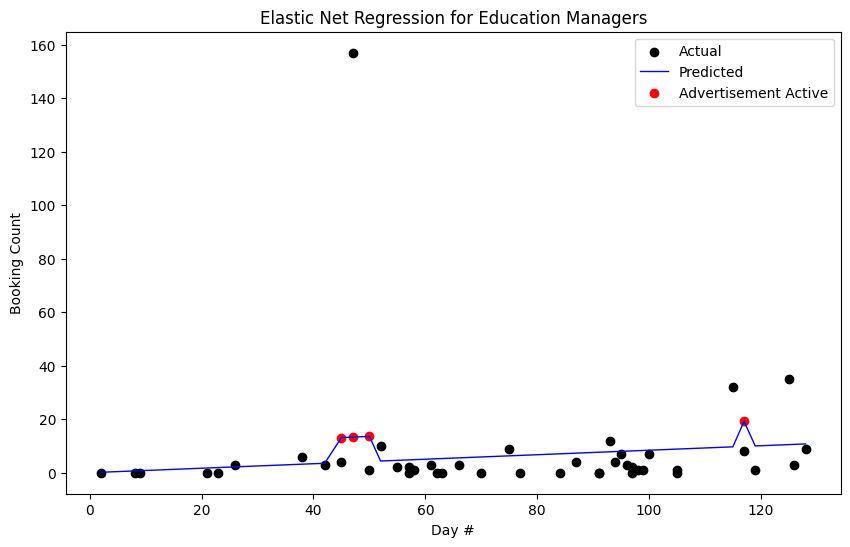

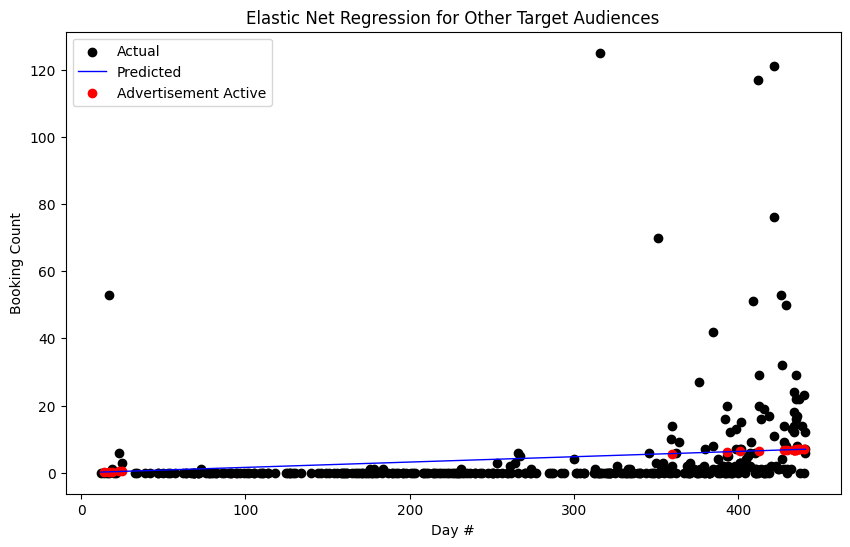

               Target Audience   Alpha  L1 Ratio  Mean Squared Error  \
0                  IT Managers   12.02      0.10              225.36   
1            Property Managers    0.50      0.99                8.26   
2  Education Property Managers  121.02      0.10              774.04   
3           Education Managers    0.61      0.99              524.81   
4       Other Target Audiences   13.73      0.10              201.19   

   R-squared  % R-squared  % Relative MSE  Mean Absolute Error  Relative MAE  \
0       0.05         5.23           94.77                 5.71          0.05   
1       0.20        19.83           80.17                 1.88          0.08   
2      -0.08        -8.45          108.45                19.03          0.20   
3       0.08         7.95           92.05                 8.82          0.06   
4       0.05         5.30           94.70                 6.12          0.05   

   % Accuracy  % Booking Increase per Day in Advertisement Weeks  
0       95.44      

In [4]:
elastic_net(df_ITM_days, "IT Managers")
elastic_net(df_PM_days, "Property Managers")
elastic_net(df_EPM_days, "Education Property Managers")
elastic_net(df_EM_days, "Education Managers")
elastic_net(df_other_days, "Other Target Audiences")

print(df_elasticnet_results)